# Diabetic Retinopathy Stage Detection
## Notebook 1 of 2 — Data Acquisition, Exploratory Analysis & Preprocessing

**Module:** Computer Vision | **Coursework 1** | BSc (Hons) Computer Science

---

### Purpose of this notebook

This notebook covers dataset acquisition, exploratory analysis, and preprocessing:

1. **Dataset audit** — class distribution, image properties, and split strategy.
2. **Preprocessing pipeline** — a retinal-specific pipeline with visual and quantitative
   evidence that it improves image quality.
3. **Class imbalance** — quantified here; handled during training in Notebook 2.

### What it produces

1. A cached set of preprocessed images (`processed_320.zip` on Google Drive) so that
   preprocessing is done **once**, not on every training run.
2. Stratified train / validation / test split files.
3. A folder of figures documenting each step.

### Runtime requirements

No GPU is required for this notebook — a standard CPU runtime is sufficient.
Preprocessing all 3,662 images takes roughly 7–10 minutes.

---
## 1. Environment verification

The exact software environment is recorded first, as part of reproducibility.

In [1]:
# --- Environment check -------------------------------------------------------
import sys, os, platform, json, random, shutil, zipfile, time
from pathlib import Path

import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python      :", sys.version.split()[0])
print("TensorFlow  :", tf.__version__)
print("NumPy       :", np.__version__)
print("Platform    :", platform.platform())

gpus = tf.config.list_physical_devices("GPU")
print("GPU devices :", gpus if gpus else "NONE  <-- enable Runtime > Change runtime type > T4 GPU")

Python      : 3.13.15
TensorFlow  : 2.20.0
NumPy       : 2.1.3
Platform    : Linux-6.6.122+-x86_64-with-glibc2.39
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Report the GPU if one is attached (not required for this notebook)
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader 2>/dev/null || echo "No GPU attached - not required for preprocessing"

Tesla T4, 15360 MiB, 580.82.07


---
## 2. Project paths

**Design decision:** images are processed on Colab's *local* disk (`/content`, fast SSD)
and only the final archive is copied to Google Drive. Writing thousands of small files
directly to a mounted Drive is I/O-bound and can take 20x longer.

Everything the report needs — figures, CSVs, models — is written to Drive so it survives
a runtime disconnect.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

# --- Directory layout --------------------------------------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/DR_CW")   # persistent (Google Drive)
ARTIFACT_DIR = PROJECT_DIR / "artifacts"             # figures + CSVs for the report
FIG_DIR      = ARTIFACT_DIR / "figures"
SPLIT_DIR    = ARTIFACT_DIR / "splits"

RAW_DIR      = Path("/content/raw")                  # ephemeral (local disk)
PROC_DIR     = Path("/content/processed")

for d in (PROJECT_DIR, ARTIFACT_DIR, FIG_DIR, SPLIT_DIR, RAW_DIR, PROC_DIR):
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 320   # cached at 320 so we can train at 224 (EfficientNetB0) or 300 (B3)

print("Drive project dir :", PROJECT_DIR)
print("Cached image size :", IMG_SIZE)

Mounted at /content/drive
Drive project dir : /content/drive/MyDrive/DR_CW
Cached image size : 320


In [4]:
import matplotlib.pyplot as plt

# --- Consistent figure styling + one-call saving -----------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,          # crisp enough to embed in the PDF report
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def save_fig(name: str):
    '''Save the current matplotlib figure into the report figures folder.'''
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path)
    print(f"  saved -> {path.name}")
    return path

---
## 3. Dataset acquisition — APTOS 2019 Blindness Detection

### Why this dataset

- **Clinically graded fundus photographs** from Aravind Eye Hospital, India, labelled by
  trained clinicians on the 5-point International Clinical DR Severity Scale.
- **Ordinal 5-class problem** (0 No DR → 4 Proliferative DR), which matches the
  requirement to classify *the stage* of the disease, not just its presence.
- **Realistic difficulty**: images were captured over a long period, across multiple
  clinics, with varying cameras and lighting — the kind of domain variation a deployed
  screening system faces.
- **Tractable size** (~3.6k images) for a single cloud GPU, unlike EyePACS (~35k images).

### Source and provenance

The original data was released through the APTOS 2019 Blindness Detection competition
(Asia Pacific Tele-Ophthalmology Society). Downloading from the competition page requires
Kaggle identity verification, so the data is obtained here from a public Kaggle mirror,
[`mariaherrerot/aptos2019`](https://www.kaggle.com/datasets/mariaherrerot/aptos2019),
which redistributes the same 3,662 labelled images at their **original resolution**.
The mirror's license is listed as *Unknown* on Kaggle; the data is used here solely for
non-commercial academic coursework.

### Credentials

1. Kaggle ▸ profile icon ▸ **Settings** ▸ **API** ▸ *Generate New Token* → downloads a token file.
2. Run the cell below and upload that file when prompted.

In [5]:
# --- Kaggle API authentication (updated for the new access_token flow) ------
!pip install -q --upgrade kaggle
!kaggle --version

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

from google.colab import files
print("Upload the Kaggle API token file (kaggle.com/settings > API > Generate New Token):")
uploaded = files.upload()

fname = list(uploaded.keys())[0]
print("Uploaded file name:", fname)

if fname.endswith(".json"):
    # old-style kaggle.json (username + key)
    !mv "{fname}" /root/.kaggle/kaggle.json
    !chmod 600 /root/.kaggle/kaggle.json
    print("Saved as kaggle.json")
else:
    # new-style plain token
    !mv "{fname}" /root/.kaggle/access_token
    !chmod 600 /root/.kaggle/access_token
    print("Saved as access_token")

# Auth test - should list the mirror dataset
!kaggle datasets list -s aptos2019 | head -5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.5 MB/s eta 0:00:00
Kaggle CLI 2.2.4
Upload the Kaggle API token file (kaggle.com/settings > API > Generate New Token):


Saving kaggle.json to kaggle.json
Uploaded file name: kaggle.json
Saved as kaggle.json
ref                                                                      title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
aitude/aptos-augmented-images                                            APTOS2019 - 10K Augmented Images                     2969245178  2019-08-20 16:55:54.103000           1365         25  0.8125           
raimonds1993/aptos2019traineddenset                                      Aptos2019-trained-denset                               75940148  2019-07-22 15:15:54.267000            173          9  0.7647059        
paraspatil/aptos2019blindnessdetection                                   

In [6]:
# --- Download the public mirror (original-resolution images) -------------
if not any(RAW_DIR.rglob("*.csv")):
    !kaggle datasets download -d mariaherrerot/aptos2019 -p {RAW_DIR} --unzip
    print("Extracted.\n")
else:
    print("Dataset already present.\n")

# Inspect what we actually got - folder layout and real image resolutions
!find {RAW_DIR} -maxdepth 2 | head -20

import glob, cv2
imgs = glob.glob(f"{RAW_DIR}/**/*.png", recursive=True) + \
       glob.glob(f"{RAW_DIR}/**/*.jpg", recursive=True)
print(f"\nImage files found: {len(imgs)}")
for f in imgs[:6]:
    print("  ", cv2.imread(f).shape, f.split("/")[-1])

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [01:15<00:00, 115MB/s]

Extracted.

/content/raw
/content/raw/test_images
/content/raw/test_images/test_images
/content/raw/valid.csv
/content/raw/train_1.csv
/content/raw/val_images
/content/raw/val_images/val_images
/content/raw/train_images
/content/raw/train_images/train_images
/content/raw/test.csv

Image files found: 3662
   (1736, 2416, 3) eaa0dfbd5024.png
   (1736, 2416, 3) ed2c06fcc573.png
   (614, 819, 3) e5197d77ec68.png
   (1536, 2048, 3) f0267c42907c.png
   (1050, 1050, 3) e66ad813a508.png
   (2136, 3216, 3) f460608cf4cc.png


---
## 4. Exploratory data analysis

The competition's own test set is **unlabelled** (its labels were withheld for scoring),
so it cannot be used for evaluation. The mirror instead provides the 3,662 *labelled*
images pre-divided into three folders (`train_1.csv`, `valid.csv`, `test.csv`).

These three parts are **pooled into a single set** and re-split in Section 7 with our own
stratified 70 / 15 / 15 partition. This gives full control over the split and guarantees
that every class is represented in the same proportion in train, validation and test.
The reported test accuracy therefore comes from a held-out split created here.

In [7]:
import os
for sub in ["train_images/train_images", "val_images/val_images", "test_images/test_images"]:
    p = RAW_DIR / sub
    if p.exists():
        files = os.listdir(p)
        print(f"{sub}: {len(files)} files, example: {files[0]}")
    else:
        print(f"{sub}: MISSING")

train_images/train_images: 2930 files, example: d1f1ea894da1.png
val_images/val_images: 366 files, example: 070f67572d03.png
test_images/test_images: 366 files, example: eaa0dfbd5024.png


In [8]:
import pandas as pd

# Load the three labelled partitions shipped with the mirror dataset.
df1 = pd.read_csv(RAW_DIR / "train_1.csv")
df2 = pd.read_csv(RAW_DIR / "valid.csv")
df3 = pd.read_csv(RAW_DIR / "test.csv")
for name, d in [("train_1", df1), ("valid", df2), ("test", df3)]:
    print(f"{name:<8} {d.shape[0]:>5} rows  columns={list(d.columns)}")

# Pool all three into one set - our own stratified split is built in Section 7.
df1["split_folder"] = "train_images/train_images"
df2["split_folder"] = "val_images/val_images"
df3["split_folder"] = "test_images/test_images"

df = pd.concat([df1, df2, df3], ignore_index=True)
df["path"] = df.apply(lambda r: str(RAW_DIR / r["split_folder"] / f"{r['id_code']}.png"), axis=1)

CLASS_NAMES = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}
df["label"] = df["diagnosis"].map(CLASS_NAMES)

print(f"\nTotal pooled images   : {len(df)}")
print(f"Files present on disk : {df['path'].apply(os.path.exists).sum()}")
df.head()

train_1   2930 rows  columns=['id_code', 'diagnosis']
valid      366 rows  columns=['id_code', 'diagnosis']
test       366 rows  columns=['id_code', 'diagnosis']

Total pooled images   : 3662
Files present on disk : 3662


,id_code,diagnosis,split_folder,path,label
0,1ae8c165fd53,2,train_images/train_images,/content/raw/train_images/train_images/1ae8c16...,Moderate
1,1b329a127307,1,train_images/train_images,/content/raw/train_images/train_images/1b329a1...,Mild
2,1b32e1d775ea,4,train_images/train_images,/content/raw/train_images/train_images/1b32e1d...,Proliferative DR
3,1b3647865779,0,train_images/train_images,/content/raw/train_images/train_images/1b36478...,No DR
4,1b398c0494d1,0,train_images/train_images,/content/raw/train_images/train_images/1b398c0...,No DR


,class,count,percent,imbalance_ratio
0,No DR,1805,49.3,1.0
1,Mild,370,10.1,4.9
2,Moderate,999,27.3,1.8
3,Severe,193,5.3,9.4
4,Proliferative DR,295,8.1,6.1


  saved -> 01_class_distribution.png


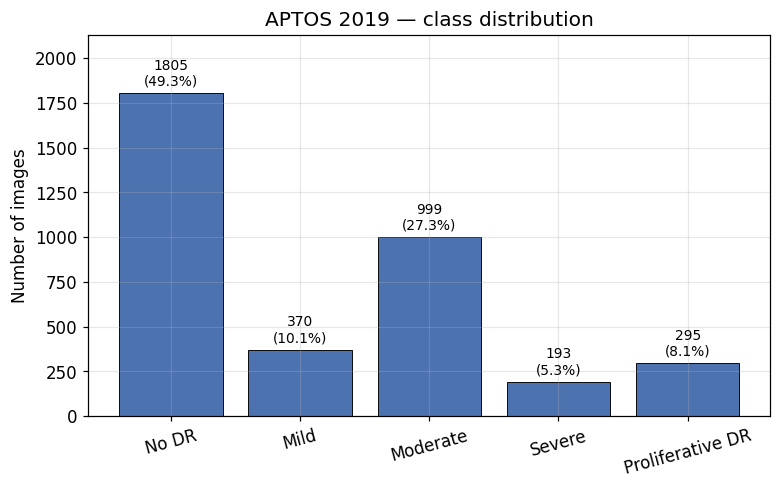


Most frequent class is 9x the rarest.
=> Imbalance must be addressed (class weights / weighted sampling) in Notebook 2.


In [9]:
# --- Class distribution ------------------------------------------------------
counts = df["diagnosis"].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(1)

dist = pd.DataFrame({
    "class": [CLASS_NAMES[i] for i in counts.index],
    "count": counts.values,
    "percent": pct.values,
})
dist["imbalance_ratio"] = (counts.max() / counts).round(1).values
display(dist)

dist.to_csv(ARTIFACT_DIR / "class_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dist["class"], dist["count"], color="#4C72B0", edgecolor="black", linewidth=0.6)
ax.bar_label(bars, labels=[f"{c}\n({p}%)" for c, p in zip(dist['count'], dist['percent'])],
             fontsize=9, padding=3)
ax.set_ylabel("Number of images")
ax.set_title("APTOS 2019 — class distribution")
ax.set_ylim(0, dist["count"].max() * 1.18)
plt.xticks(rotation=15)
save_fig("01_class_distribution")
plt.show()

print(f"\nMost frequent class is {dist['imbalance_ratio'].max():.0f}x the rarest.")
print("=> Imbalance must be addressed (class weights / weighted sampling) in Notebook 2.")

**Interpreting this chart.** The imbalance is not a data-collection flaw: DR screening
populations are dominated by patients with no retinopathy, and the advanced stages
(Severe, Proliferative) are genuinely rare. It reflects real prevalence — which is
precisely why plain accuracy is a misleading metric here, and why per-class recall and
quadratic weighted kappa are reported instead.

  saved -> 02_sample_images_by_class.png


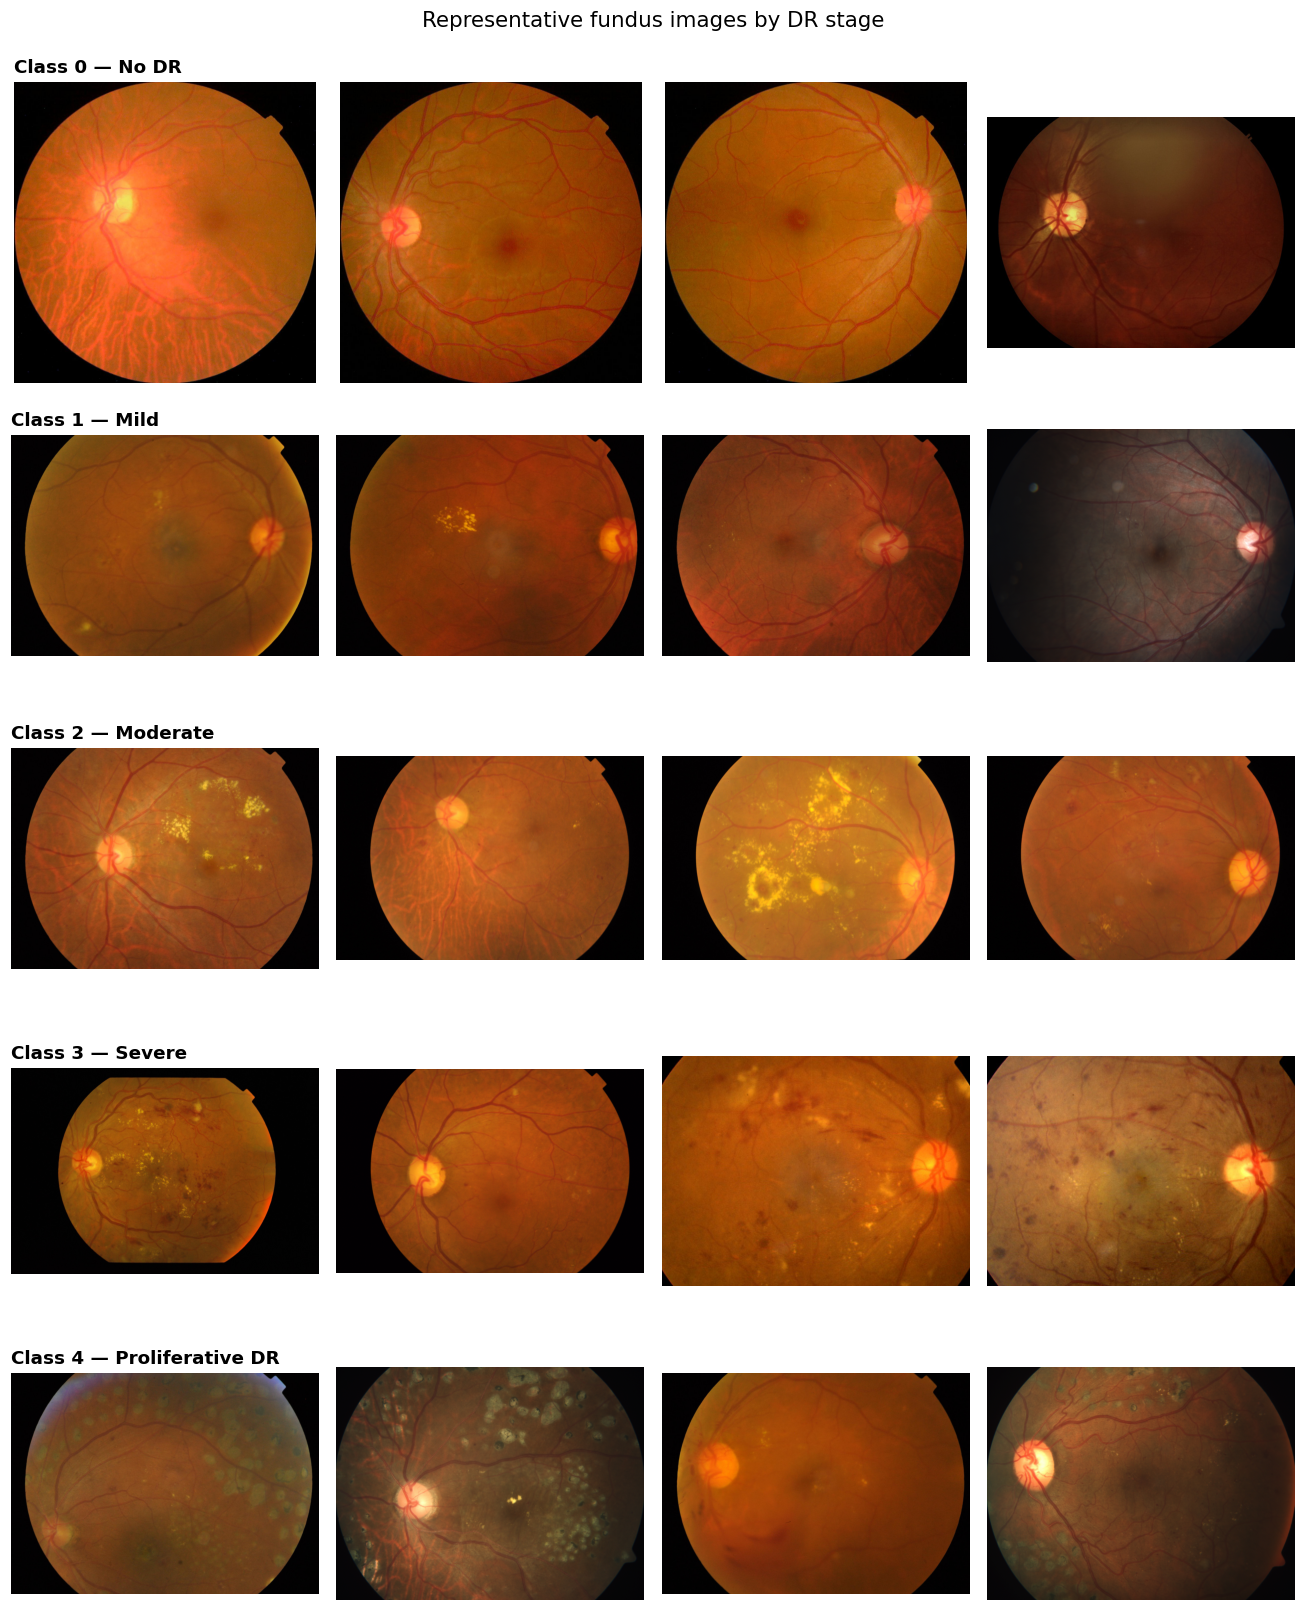

In [10]:
# --- Sample images, one row per class ----------------------------------------
import cv2

def load_rgb(path):
    '''Read an image from disk as RGB (OpenCV loads BGR by default).'''
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

N_SHOW = 4
fig, axes = plt.subplots(5, N_SHOW, figsize=(3 * N_SHOW, 15))
for cls in range(5):
    subset = df[df["diagnosis"] == cls].sample(N_SHOW, random_state=SEED)
    for j, (_, row) in enumerate(subset.iterrows()):
        ax = axes[cls, j]
        ax.imshow(load_rgb(row["path"]))
        ax.axis("off")
        if j == 0:
            ax.set_title(f"Class {cls} — {CLASS_NAMES[cls]}", loc="left",
                         fontsize=12, fontweight="bold")
plt.suptitle("Representative fundus images by DR stage", fontsize=14, y=0.995)
plt.tight_layout()
save_fig("02_sample_images_by_class")
plt.show()

In [11]:
# --- Image property audit ----------------------------------------------------
# Sampled rather than exhaustive: reading 3.6k full-resolution PNGs is slow and
# a 400-image sample is ample to characterise the distribution.
from tqdm.auto import tqdm

sample = df.sample(min(400, len(df)), random_state=SEED)
records = []
for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Auditing images"):
    img = load_rgb(row["path"])
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    informative = (gray > 7).mean()          # fraction of non-black pixels
    records.append({
        "height": h, "width": w,
        "aspect": round(w / h, 3),
        "megapixels": round(h * w / 1e6, 2),
        "mean_brightness": gray.mean(),
        "informative_fraction": informative,
        "diagnosis": row["diagnosis"],
    })

audit = pd.DataFrame(records)
display(audit.describe().round(2))
audit.describe().round(2).to_csv(ARTIFACT_DIR / "image_property_audit.csv")

print("\nDistinct resolutions in sample:", audit.groupby(['width','height']).size().shape[0])
print(f"Black border wastes on average {(1 - audit['informative_fraction'].mean())*100:.0f}% "
      f"of every image.")

Auditing images:   0%|          | 0/400 [00:00<?, ?it/s]

,height,width,aspect,megapixels,mean_brightness,informative_fraction,diagnosis
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,1509.93,1980.88,1.27,3.42,67.98,0.77,1.16
std,513.57,865.58,0.19,2.46,17.40,0.13,1.33
min,480.00,640.00,1.00,0.31,17.70,0.47,0.00
25%,1050.00,1050.00,1.00,1.10,54.62,0.75,0.00
50%,1536.00,2048.00,1.33,3.15,70.34,0.79,1.00
75%,1958.00,2588.00,1.39,5.07,80.83,0.83,2.00
max,2848.00,4288.00,1.51,12.21,121.43,1.00,4.00



Distinct resolutions in sample: 14
Black border wastes on average 23% of every image.


  saved -> 03_image_property_audit.png


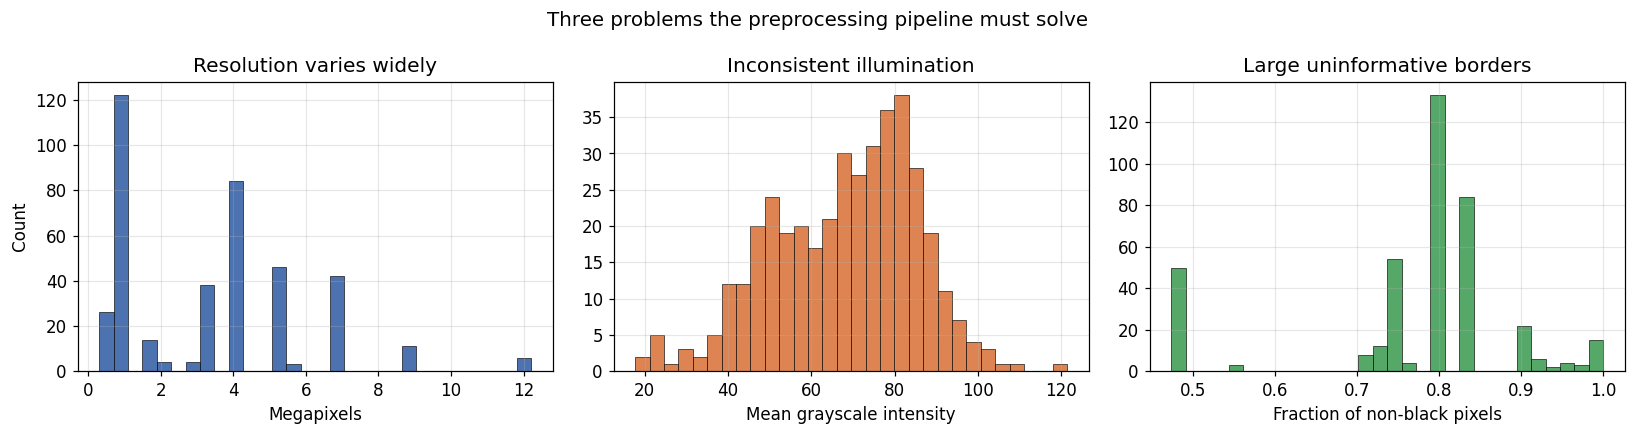

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(audit["megapixels"], bins=30, color="#4C72B0", edgecolor="black", linewidth=0.4)
axes[0].set_xlabel("Megapixels"); axes[0].set_ylabel("Count")
axes[0].set_title("Resolution varies widely")

axes[1].hist(audit["mean_brightness"], bins=30, color="#DD8452", edgecolor="black", linewidth=0.4)
axes[1].set_xlabel("Mean grayscale intensity")
axes[1].set_title("Inconsistent illumination")

axes[2].hist(audit["informative_fraction"], bins=30, color="#55A868", edgecolor="black", linewidth=0.4)
axes[2].set_xlabel("Fraction of non-black pixels")
axes[2].set_title("Large uninformative borders")

plt.suptitle("Three problems the preprocessing pipeline must solve", fontsize=13)
plt.tight_layout()
save_fig("03_image_property_audit")
plt.show()

**This figure justifies the preprocessing pipeline.** Rather than applying generic
preprocessing, three specific defects were measured in the raw data, and each pipeline
stage is designed to correct one of them:

| Measured defect | Pipeline response |
|---|---|
| Resolution varies from ~0.3 to ~12 MP across 14 distinct sizes | Border crop then uniform resize to 320×320 |
| Mean brightness varies widely between images | CLAHE on the luminance channel |
| On average ~23% of every frame is black background | Tight bounding-box crop + circular mask |
| Lesions (microaneurysms, exudates) are low-contrast | Ben Graham edge enhancement |

---
## 5. The preprocessing pipeline

Four stages, each addressing a defect identified above.

**Stage 1 — Bounding-box crop.** Fundus photographs are a circular retina on a black
rectangle. The tightest box containing non-black pixels is found and cropped to, removing
dead pixels that would otherwise consume resolution after resizing.

**Stage 2 — Circular mask.** After cropping, corner regions are still background. Masking
them to a uniform value stops the CNN from keying on camera-specific corner artefacts.

**Stage 3 — Contrast enhancement: CLAHE (Contrast Limited Adaptive Histogram
Equalisation).** Applied to the **L channel of LAB colour space**, not to RGB. Equalising
RGB channels independently shifts hue; equalising only luminance preserves the colour
relationships that distinguish haemorrhages (dark red) from hard exudates (bright yellow).

**Stage 4 — Edge enhancement: Ben Graham local-average subtraction.** From the winning
solution of the 2015 Kaggle Diabetic Retinopathy competition. Subtracting a heavily
Gaussian-blurred copy of the image is a **high-pass (unsharp-mask) filter**: it removes
smooth illumination gradients while amplifying edges and small high-frequency structures —
which is exactly what vessel boundaries and early-stage DR lesions are.

Formula: `output = 4 * image - 4 * GaussianBlur(image, sigma) + 128`

### Parameter choices

| Parameter | Value | Reason |
|---|---|---|
| CLAHE `clipLimit` | 2.0 | Standard value; higher limits amplify sensor noise in dark regions |
| CLAHE tile grid | 8×8 | Each tile (~40 px at 320 px) is local enough to correct uneven illumination |
| Ben Graham `sigma` | 10 | Blur scale larger than lesions (a few px) but smaller than illumination gradients, so lesions are kept and gradients removed |
| Circular mask `shrink` | 0.97 | Removes the bright rim artefact some cameras produce at the aperture edge |
| Output size | 320×320 | Allows training at 224 (EfficientNetB0) or 300 (B3) from one cache |

In [13]:
# --- Preprocessing primitives ------------------------------------------------

def crop_to_content(img: np.ndarray, tol: int = 7) -> np.ndarray:
    '''Crop to the tightest bounding box of pixels brighter than `tol`.

    Removes the black letterboxing around the circular retinal field of view.
    Returns the original image unchanged if the image is entirely dark.
    '''
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if not mask.any():
        return img
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]


def pad_to_square(img: np.ndarray) -> np.ndarray:
    '''Zero-pad the shorter side so resizing does not distort the retina's aspect ratio.'''
    h, w = img.shape[:2]
    size = max(h, w)
    top, left = (size - h) // 2, (size - w) // 2
    canvas = np.zeros((size, size, 3), dtype=img.dtype)
    canvas[top:top + h, left:left + w] = img
    return canvas


def circular_mask(img: np.ndarray, shrink: float = 0.97) -> np.ndarray:
    '''Blank out everything outside the inscribed circle (the field of view).

    `shrink` pulls the radius in slightly to remove the bright rim artefact that
    some fundus cameras produce at the edge of the aperture.
    '''
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) // 2 * shrink), 1, thickness=-1)
    return img * mask[..., None]


def apply_clahe(img: np.ndarray, clip: float = 2.0, grid: int = 8) -> np.ndarray:
    '''Adaptive contrast enhancement on the LAB luminance channel only.'''
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)


def ben_graham(img: np.ndarray, sigma: int = 10) -> np.ndarray:
    '''Subtract the local colour average to expose low-contrast lesions.'''
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(img, 4, blurred, -4, 128)

In [14]:
def preprocess(path, size: int = IMG_SIZE, use_clahe: bool = True,
               use_ben: bool = True, sigma: int = 10) -> np.ndarray:
    '''Full pipeline: disk path in, size x size x 3 uint8 RGB array out.'''
    img = load_rgb(path)
    img = crop_to_content(img)
    img = pad_to_square(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    if use_clahe:
        img = apply_clahe(img)
    if use_ben:
        img = ben_graham(img, sigma=sigma)
    img = circular_mask(img)
    return img

### 5.1 Visual evidence — variant comparison

Rather than asserting that this pipeline is the right one, four variants are rendered side
by side. The final column should show detail — vessel edges, exudates, small haemorrhages —
that is faint or invisible in the raw first column.

  saved -> 04_preprocessing_variants.png


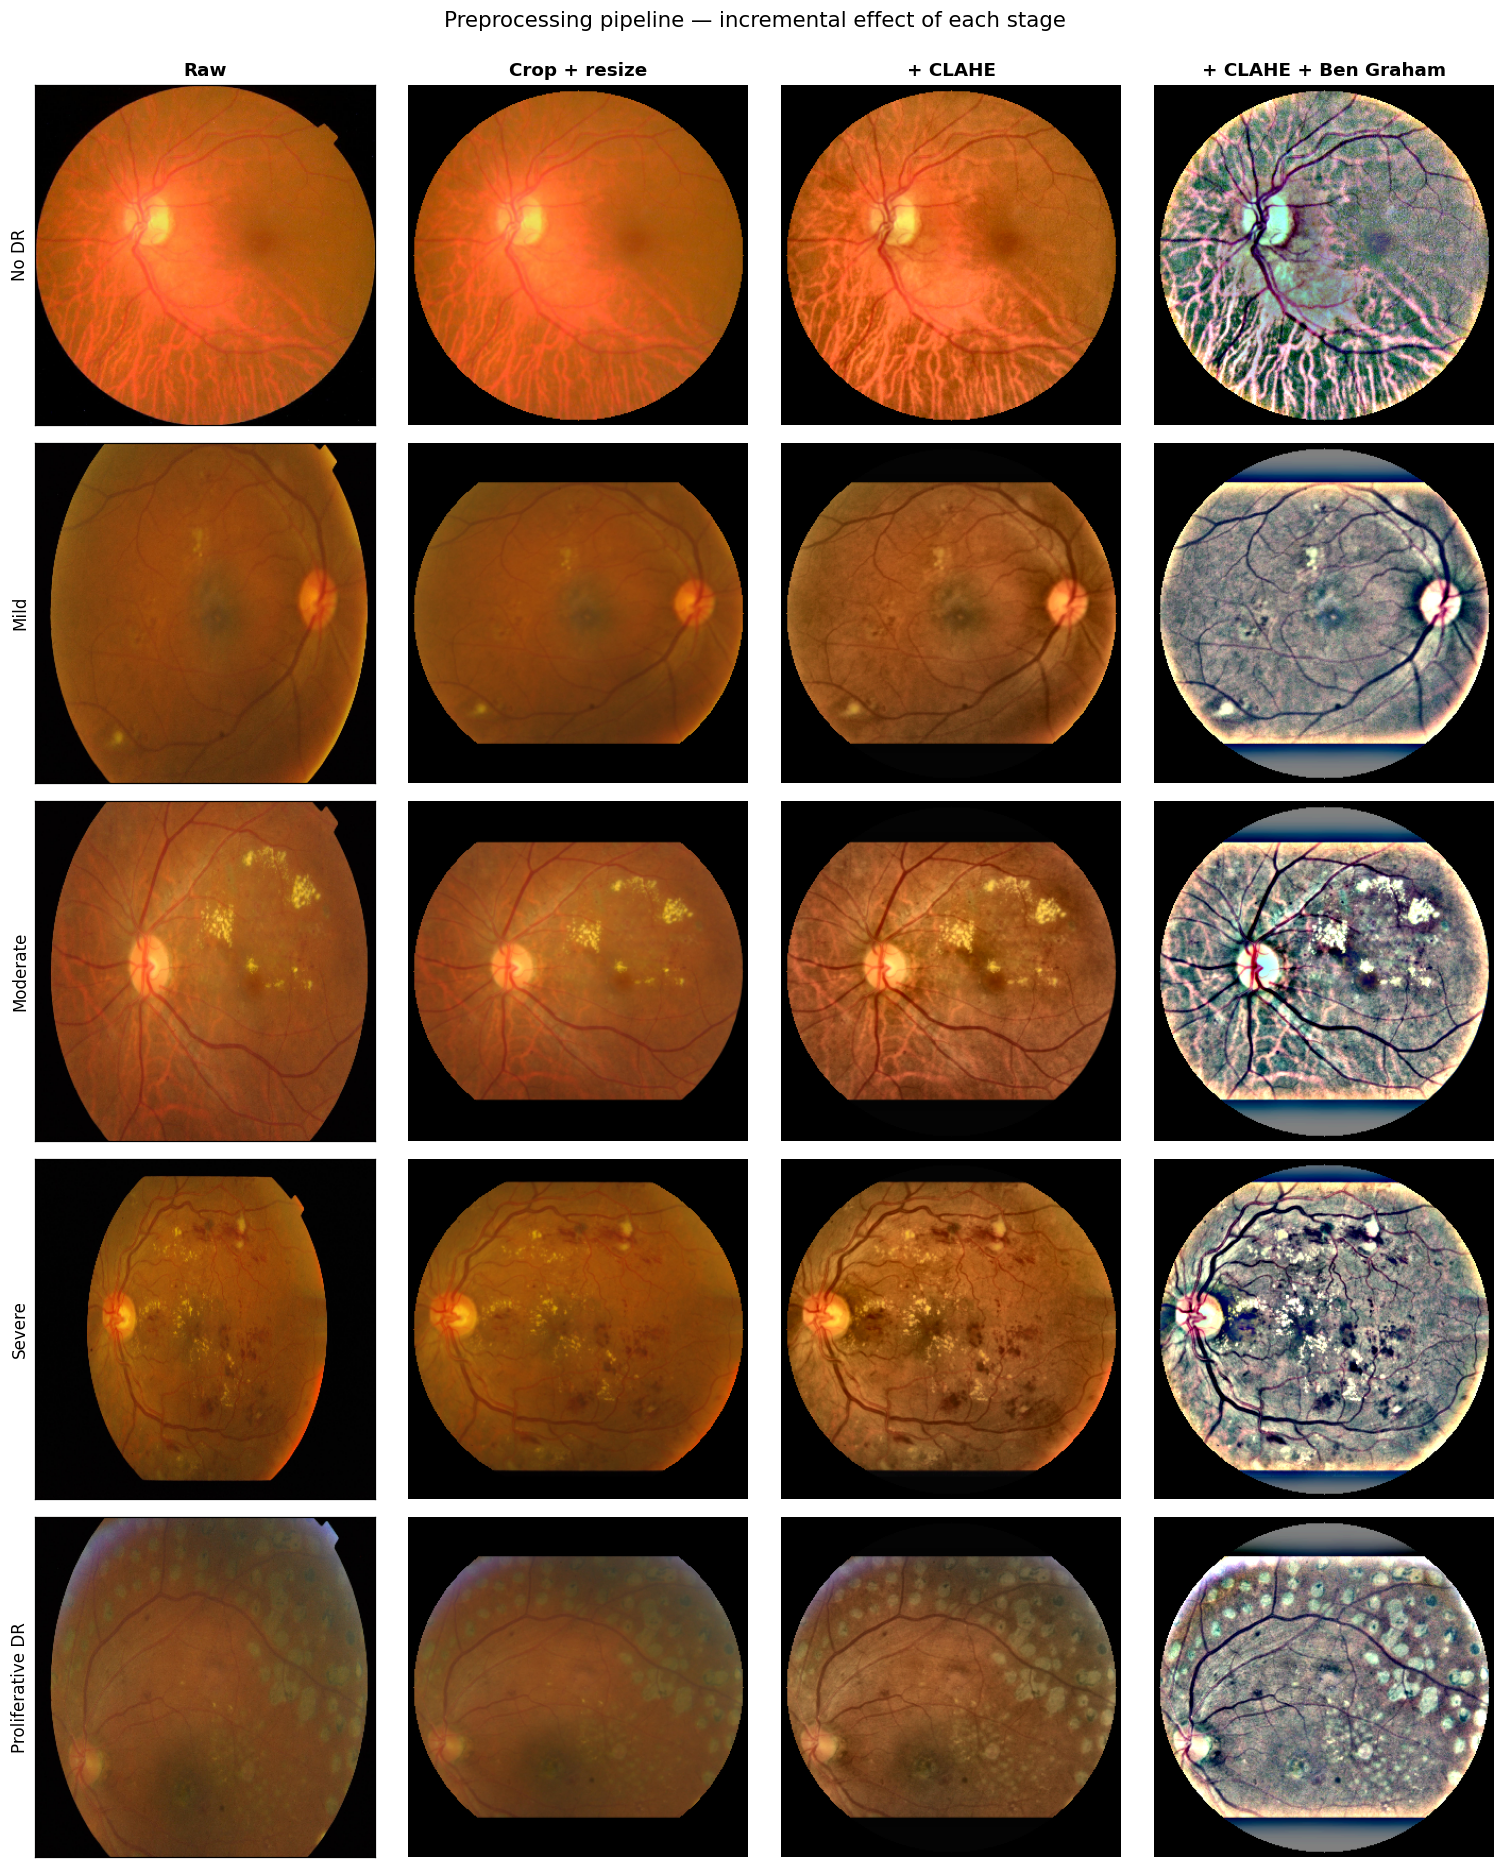

In [15]:
variants = [
    ("Raw",              dict(use_clahe=False, use_ben=False)),
    ("Crop + resize",    dict(use_clahe=False, use_ben=False)),   # geometry only
    ("+ CLAHE",          dict(use_clahe=True,  use_ben=False)),
    ("+ CLAHE + Ben Graham", dict(use_clahe=True, use_ben=True)),
]

# One example per class so the comparison spans severity levels
examples = [df[df["diagnosis"] == c].sample(1, random_state=SEED).iloc[0] for c in range(5)]

fig, axes = plt.subplots(len(examples), 4, figsize=(14, 3.4 * len(examples)))
for i, row in enumerate(examples):
    for j, (name, kwargs) in enumerate(variants):
        if j == 0:
            img = cv2.resize(load_rgb(row["path"]), (IMG_SIZE, IMG_SIZE))
        else:
            img = preprocess(row["path"], **kwargs)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(name, fontsize=12, fontweight="bold")
    axes[i, 0].set_ylabel(CLASS_NAMES[row["diagnosis"]])
    axes[i, 0].axis("on"); axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])

plt.suptitle("Preprocessing pipeline — incremental effect of each stage", fontsize=14, y=0.997)
plt.tight_layout()
save_fig("04_preprocessing_variants")
plt.show()

Measuring contrast:   0%|          | 0/120 [00:00<?, ?it/s]

  saved -> 05_contrast_before_after.png


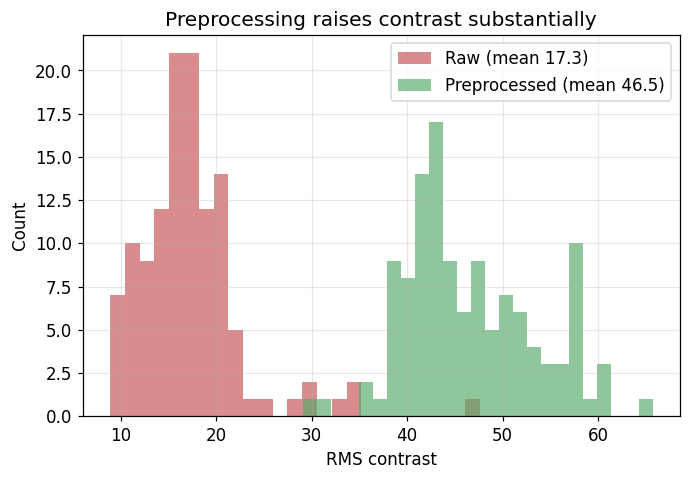

Mean RMS contrast: 17.32 -> 46.53 (+168.6%)
Std of contrast  : 5.50 -> 6.89  (absolute spread)
Coeff. variation : 0.318 -> 0.148  (relative spread - lower = more consistent across images)


In [16]:
# --- Quantitative check: does the pipeline actually improve contrast? --------
# Visual improvement is subjective; a metric makes the claim defensible.

def rms_contrast(img):
    '''Root-mean-square contrast over the informative (non-masked) region.'''
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
    region = gray[gray > 7]
    return float(region.std()) if region.size else 0.0

check = df.sample(120, random_state=SEED)
before, after = [], []
for _, row in tqdm(check.iterrows(), total=len(check), desc="Measuring contrast"):
    raw = cv2.resize(load_rgb(row["path"]), (IMG_SIZE, IMG_SIZE))
    before.append(rms_contrast(raw))
    after.append(rms_contrast(preprocess(row["path"])))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(before, bins=25, alpha=0.65, label=f"Raw (mean {np.mean(before):.1f})", color="#C44E52")
ax.hist(after,  bins=25, alpha=0.65, label=f"Preprocessed (mean {np.mean(after):.1f})", color="#55A868")
ax.set_xlabel("RMS contrast"); ax.set_ylabel("Count")
ax.set_title("Preprocessing raises contrast substantially")
ax.legend()
save_fig("05_contrast_before_after")
plt.show()

print(f"Mean RMS contrast: {np.mean(before):.2f} -> {np.mean(after):.2f} "
      f"({(np.mean(after)/np.mean(before)-1)*100:+.1f}%)")
# Absolute spread (std) grows because the values themselves are larger. The
# coefficient of variation (std / mean) is the scale-free measure of consistency.
cv_before = np.std(before) / np.mean(before)
cv_after  = np.std(after)  / np.mean(after)
print(f"Std of contrast  : {np.std(before):.2f} -> {np.std(after):.2f}  (absolute spread)")
print(f"Coeff. variation : {cv_before:.3f} -> {cv_after:.3f}  "
      f"(relative spread - lower = more consistent across images)")

---
## 6. Batch processing and caching

Preprocessing all images takes several minutes. Doing it inside the training loop would
repeat that cost on every epoch and every reconnect, so we do it **once** and cache.

The loop is written to be **resumable**: if the Colab session drops halfway, rerunning
skips whatever is already on disk.

In [17]:
from concurrent.futures import ProcessPoolExecutor

OUT_DIR = PROC_DIR / f"images_{IMG_SIZE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def process_one(args):
    '''Worker: preprocess a single image and write it as JPEG. Returns (id, ok, msg).'''
    id_code, src = args
    dst = OUT_DIR / f"{id_code}.jpg"
    if dst.exists():
        return (id_code, True, "cached")
    try:
        img = preprocess(src)
        cv2.imwrite(str(dst), cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                    [int(cv2.IMWRITE_JPEG_QUALITY), 95])
        return (id_code, True, "ok")
    except Exception as e:
        return (id_code, False, str(e))

tasks = list(zip(df["id_code"], df["path"]))
t0 = time.time()

results = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for r in tqdm(ex.map(process_one, tasks, chunksize=16),
                  total=len(tasks), desc="Preprocessing"):
        results.append(r)

failed = [r for r in results if not r[1]]
print(f"\nProcessed {len(results) - len(failed)}/{len(results)} images "
      f"in {time.time() - t0:.0f}s")
if failed:
    print("FAILURES:", failed[:10])

Preprocessing:   0%|          | 0/3662 [00:00<?, ?it/s]


Processed 3662/3662 images in 417s


Cached files: 3662


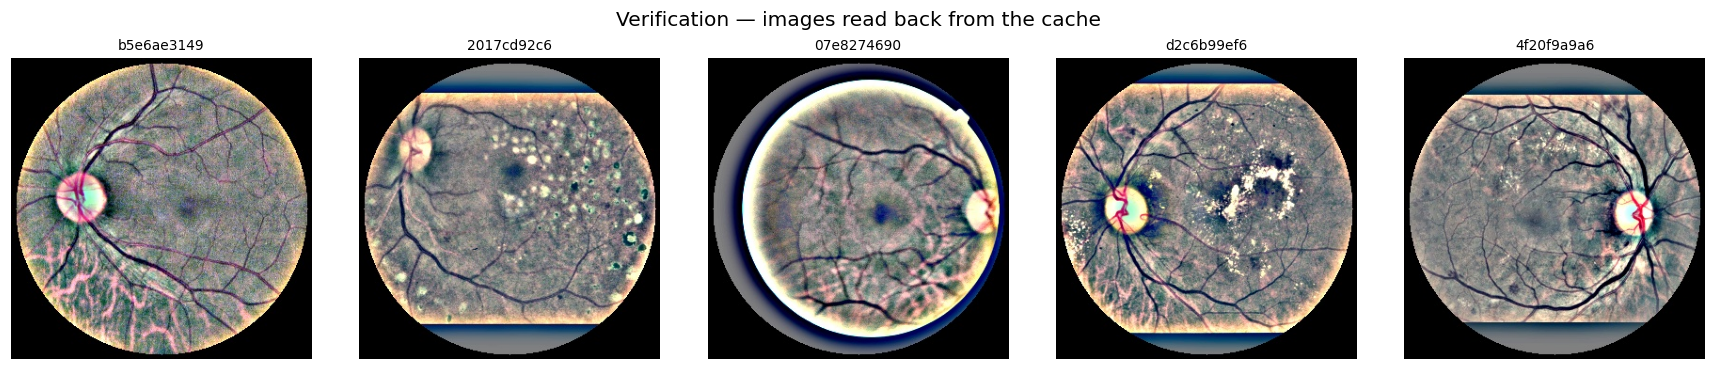

Cache size: 218 MB


In [18]:
# --- Sanity check: read back a few cached images -----------------------------
cached = sorted(OUT_DIR.glob("*.jpg"))
print(f"Cached files: {len(cached)}")

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, p in zip(axes, random.sample(cached, 5)):
    ax.imshow(load_rgb(p)); ax.axis("off"); ax.set_title(p.stem[:10], fontsize=9)
plt.suptitle("Verification — images read back from the cache")
plt.tight_layout(); plt.show()

size_mb = sum(p.stat().st_size for p in cached) / 1e6
print(f"Cache size: {size_mb:.0f} MB")

In [19]:
# --- Archive to Drive (one large file, not thousands of small ones) ----------
archive_local = Path(f"/content/processed_{IMG_SIZE}.zip")
archive_drive = PROJECT_DIR / archive_local.name

if not archive_drive.exists():
    print("Zipping...")
    !cd {PROC_DIR} && zip -qr {archive_local} images_{IMG_SIZE}
    print("Copying to Drive...")
    shutil.copy(archive_local, archive_drive)

print("Archive on Drive:", archive_drive, f"({archive_drive.stat().st_size/1e6:.0f} MB)")
print("\nNotebook 2 restores this in ~30 seconds instead of re-preprocessing.")

Archive on Drive: /content/drive/MyDrive/DR_CW/processed_320.zip (217 MB)

Notebook 2 restores this in ~30 seconds instead of re-preprocessing.


---
## 7. Stratified train / validation / test split

**70 / 15 / 15, stratified by class.** Stratification matters more than usual here: with
only a couple of hundred Severe cases, a random split can easily hand the test set a
wildly unrepresentative share of them, making the reported metrics meaningless.

The split is written to CSV and **committed to Drive**. Every later experiment loads these
exact files, so model comparisons in Notebook 2 are like-for-like rather than being
confounded by different random partitions.

In [20]:
from sklearn.model_selection import train_test_split

df_split = df.copy()
df_split["cached_path"] = df_split["id_code"].apply(lambda x: str(OUT_DIR / f"{x}.jpg"))
df_split = df_split[df_split["cached_path"].apply(os.path.exists)].reset_index(drop=True)

# First carve off the test set, then split the remainder into train/validation.
train_val, test = train_test_split(
    df_split, test_size=0.15, stratify=df_split["diagnosis"], random_state=SEED)
train, val = train_test_split(
    train_val, test_size=0.1765, stratify=train_val["diagnosis"], random_state=SEED)
# 0.1765 of 85% ~= 15% of the original total

for name, part in [("train", train), ("val", val), ("test", test)]:
    part.reset_index(drop=True).to_csv(SPLIT_DIR / f"{name}.csv", index=False)
    print(f"{name:<6} {len(part):>5} images ({len(part)/len(df_split)*100:.1f}%)")

train   2562 images (70.0%)
val      550 images (15.0%)
test     550 images (15.0%)


,Full,Train,Val,Test
No DR,49.29,49.30,49.27,49.27
Mild,10.10,10.07,10.18,10.18
Moderate,27.28,27.28,27.27,27.27
Severe,5.27,5.27,5.27,5.27
Proliferative DR,8.06,8.08,8.00,8.00


  saved -> 06_split_stratification.png


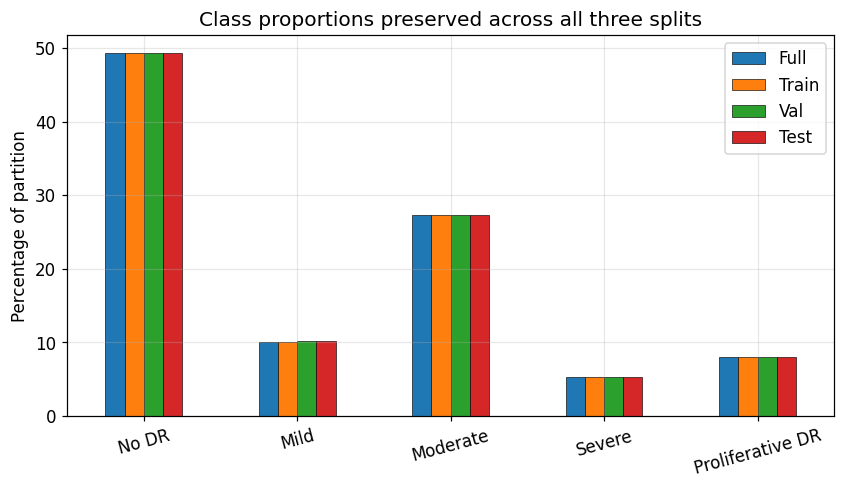

Largest deviation in any class proportion across splits: 0.11 percentage points


In [21]:
# --- Verify stratification held ---------------------------------------------
comp = pd.DataFrame({
    "Full":  df_split["diagnosis"].value_counts(normalize=True).sort_index(),
    "Train": train["diagnosis"].value_counts(normalize=True).sort_index(),
    "Val":   val["diagnosis"].value_counts(normalize=True).sort_index(),
    "Test":  test["diagnosis"].value_counts(normalize=True).sort_index(),
}).round(4) * 100
comp.index = [CLASS_NAMES[i] for i in comp.index]
display(comp.round(2))
comp.round(2).to_csv(ARTIFACT_DIR / "split_verification.csv")

ax = comp.plot(kind="bar", figsize=(9, 4.5), edgecolor="black", linewidth=0.4)
ax.set_ylabel("Percentage of partition")
ax.set_title("Class proportions preserved across all three splits")
plt.xticks(rotation=15)
save_fig("06_split_stratification")
plt.show()

max_dev = (comp.max(axis=1) - comp.min(axis=1)).max()
print(f"Largest deviation in any class proportion across splits: {max_dev:.2f} percentage points")

In [22]:
# --- Class weights for Notebook 2 -------------------------------------------
from sklearn.utils.class_weight import compute_class_weight

classes = np.sort(train["diagnosis"].unique())
weights = compute_class_weight("balanced", classes=classes, y=train["diagnosis"])
class_weights = {int(c): float(round(w, 4)) for c, w in zip(classes, weights)}

print("Balanced class weights (training set):")
for c, w in class_weights.items():
    print(f"  {c} {CLASS_NAMES[c]:<18} weight = {w:.3f}")

with open(ARTIFACT_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

Balanced class weights (training set):
  0 No DR              weight = 0.406
  1 Mild               weight = 1.986
  2 Moderate           weight = 0.733
  3 Severe             weight = 3.796
  4 Proliferative DR   weight = 2.475


---
## 8. Summary

### Artifacts written to Drive

```
MyDrive/DR_CW/
├── processed_320.zip              cached preprocessed images
└── artifacts/
    ├── class_distribution.csv
    ├── image_property_audit.csv
    ├── split_verification.csv
    ├── class_weights.json
    ├── splits/{train,val,test}.csv
    └── figures/                   figures 01-06
```

### What this notebook establishes

- **Dataset characterisation:** a 9.4× class imbalance that reflects real disease
  prevalence, the reason the competition test set is unusable, a stratified 70/15/15
  split, and the main dataset limitations — single geographic region (questionable
  generalisation to other populations), no patient metadata, and label noise inherent
  to human grading.
- **Preprocessing justification:** three measured defects in the raw images, a
  four-stage pipeline that addresses each one, and a quantitative contrast improvement.
- **Ethics:** the images are de-identified public data, but a screening model trained on
  one population should not be deployed elsewhere without revalidation, and a false
  negative on a Proliferative case carries far greater clinical cost than a false positive.

### Next: Notebook 2

Augmentation, three transfer-learning architectures, class-weighted two-stage training,
hyperparameter tuning, full evaluation including quadratic weighted kappa, Grad-CAM, and
an interactive demo.